# Probabilidad individual de desarrollar hipertensión usando variables seleccionadas por GA


In [1]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 1. Configuración de rutas

Ajusta estas rutas si tus archivos están en otra carpeta. El notebook está preparado para ejecutarse desde la raíz del proyecto.

In [2]:
DATASET_PATH = Path("trainset.csv")
TARGET_PATH = Path("trainset_target.csv")

TESTSET_PATH = Path("testset.csv")
TEST_TARGET_PATH = Path("testset_target.csv")


SELECTED_VARS_PATH = Path("output_ga/f1_models/no_grid/variables_seleccionadas_LogisticRegression.csv")

OUTPUT_DIR = Path("output_probhipertension")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Carga de datos y variables seleccionadas

La función siguiente intenta leer el CSV de variables seleccionadas aunque tenga distintos formatos habituales:

- una columna llamada `variable`, `feature`, `features`, `selected_features` o similar;
- una única columna sin nombre específico;
- una lista guardada como texto tipo `['edad_an', 'peso_kg', ...]`.

In [8]:
# Función auxiliar para poder cargar las variables seleccionadas por el algorítmo genético (GA)
def cargar_variables_seleccionadas(path: Path):
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró el CSV de variables seleccionadas: {path}. "
            "Comprueba que estás ejecutando el notebook desde la raíz del proyecto."
        )

    df_vars = pd.read_csv(path)
    if df_vars.empty:
        raise ValueError("El CSV de variables seleccionadas está vacío.")

    posibles_columnas = [
        "variable", "variables", "feature", "features", "selected_feature",
        "selected_features", "variables_seleccionadas", "best_features"
    ]

    col = None
    for c in df_vars.columns:
        if c.lower() in posibles_columnas:
            col = c
            break

    if col is None:
        # Si solo hay una columna, asumimos que contiene los nombres de las variables.
        if df_vars.shape[1] == 1:
            col = df_vars.columns[0]
        else:
            # En caso contrario, usamos la primera columna no numérica.
            non_numeric = [
                c for c in df_vars.columns
                if not pd.api.types.is_numeric_dtype(df_vars[c])
            ]
            if non_numeric:
                col = non_numeric[0]
            else:
                raise ValueError(
                    "No se pudo identificar la columna con las variables seleccionadas. "
                    f"Columnas encontradas: {df_vars.columns.tolist()}"
                )

    values = df_vars[col].dropna().astype(str).tolist()

    # Caso: una única celda con una lista en formato texto.
    if len(values) == 1 and values[0].strip().startswith("["):
        import ast
        values = ast.literal_eval(values[0])

    selected_vars = [
        str(v).strip().strip('"')
        for v in values
        if str(v).strip()
    ]

    selected_vars = list(dict.fromkeys(selected_vars))

    return selected_vars

In [9]:
df_train = pd.read_csv(DATASET_PATH)
df_train_target = pd.read_csv(TARGET_PATH)

df_test = pd.read_csv(TESTSET_PATH)
df_test_target = pd.read_csv(TEST_TARGET_PATH)

selected_vars = cargar_variables_seleccionadas(SELECTED_VARS_PATH)

print("Shape train:", df_train.shape)
print("Shape train target:", df_train_target.shape)
print("Shape test:", df_test.shape)
print("Shape test target:", df_test_target.shape)
print("Variables seleccionadas:", len(selected_vars))

Shape train: (1919, 69)
Shape train target: (1919, 1)
Shape test: (480, 69)
Shape test target: (480, 1)
Variables seleccionadas: 31


In [12]:
# Comprobación de que todas las variables seleccionadas existen en el dataset
missing_train = [v for v in selected_vars if v not in df_train.columns]
missing_test = [v for v in selected_vars if v not in df_test.columns]

if missing_train:
    raise ValueError(
        "Hay variables seleccionadas que no están en train:\n"
        + "\n".join(missing_train)
    )

if missing_test:
    raise ValueError(
        "Hay variables seleccionadas que no están en test:\n"
        + "\n".join(missing_test)
    )

X_train = df_train[selected_vars].copy()
X_test = df_test[selected_vars].copy()

y_train = df_train_target.squeeze().copy()
y_test = df_test_target.squeeze().copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución y_train:")
print(y_train.value_counts(dropna=False).sort_index())

print("\nDistribución y_test:")
print(y_test.value_counts(dropna=False).sort_index())

X_train: (1919, 31)
X_test: (480, 31)
y_train: (1919,)
y_test: (480,)

Distribución y_train:
hipertension
0    1049
1     870
Name: count, dtype: int64

Distribución y_test:
hipertension
0    263
1    217
Name: count, dtype: int64


## 5. Modelo elegido

Se usa `LogisticRegression` porque:

1. el subconjunto de variables procede del GA basado en LogisticRegression sin Grid;
2. el rendimiento previo era muy similar a alternativas más complejas;
3. es más interpretable;
4. devuelve probabilidades de forma natural.



### 5.1 Baseline

In [13]:
baseline_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train, y_train)

print("Modelo baseline entrenado correctamente.")

Modelo baseline entrenado correctamente.


### 5.2 Usando CalibratedClassifierCV

Se entrena una regresión logística calibrada mediante CalibratedClassifierCV utilizando calibración sigmoide (Platt scaling). La calibración se realiza mediante validación cruzada estratificada de cinco particiones para evaluar si las probabilidades estimadas son más fiables que las obtenidas por el modelo baseline.

In [ ]:
cv_calibration = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Compatibilidad entre versiones de scikit-learn
try:
    calibrated_model = CalibratedClassifierCV(
        estimator=baseline_model,
        method="sigmoid",
        cv=cv_calibration
    )
except TypeError:
    calibrated_model = CalibratedClassifierCV(
        base_estimator=baseline_model,
        method="sigmoid",
        cv=cv_calibration
    )

calibrated_model.fit(X_train, y_train)

print("Modelo calibrado entrenado correctamente.")

Modelo calibrado entrenado correctamente.


## 6. Evaluación del modelo

El objetivo principal de esta sección es comparar el rendimiento del modelo baseline y del modelo calibrado.

Las métricas evaluadas son:

- **Accuracy**: proporción total de pacientes correctamente clasificados.
- **Balanced Accuracy**: media entre sensibilidad y especificidad, especialmente útil en presencia de desbalanceo entre clases.
- **Sensibilidad (Recall)**: capacidad del modelo para identificar correctamente a los pacientes con hipertensión.
- **Especificidad**: capacidad del modelo para identificar correctamente a los pacientes sin hipertensión.
- **F1-score**: medida que combina precisión y sensibilidad, proporcionando una evaluación equilibrada del rendimiento.
- **G-mean**: media geométrica entre sensibilidad y especificidad, utilizada para valorar el equilibrio global del clasificador.
- **ROC-AUC**: capacidad del modelo para discriminar correctamente entre pacientes con y sin hipertensión independientemente del umbral de decisión.

Dado el contexto clínico del estudio, se presta especial atención a la sensibilidad y al número de falsos negativos.

In [20]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0


def sensitivity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0


def gmean_score(y_true, y_pred):
    sensitivity = sensitivity_score(y_true, y_pred)
    specificity = specificity_score(y_true, y_pred)
    return np.sqrt(sensitivity * specificity)

def evaluar_modelo_probabilistico(nombre, modelo, X_test, y_test, umbral=0.50):
    y_proba = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= umbral).astype(int)

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "sensibilidad": sensitivity_score(y_test, y_pred),
        "especificidad": specificity_score(y_test, y_pred),
        "g_mean": gmean_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }, y_pred, y_proba

In [21]:
metricas_baseline, y_pred_baseline, y_proba_baseline = evaluar_modelo_probabilistico(
    nombre="LogisticRegression_GA_baseline",
    modelo=baseline_model,
    X_test=X_test,
    y_test=y_test
)

metricas_calibrado, y_pred_calibrated, y_proba_calibrated = evaluar_modelo_probabilistico(
    nombre="LogisticRegression_GA_calibrada",
    modelo=calibrated_model,
    X_test=X_test,
    y_test=y_test
)

df_metricas = pd.DataFrame([
    metricas_baseline,
    metricas_calibrado
])

df_metricas

,modelo,accuracy,f1,balanced_accuracy,sensibilidad,especificidad,g_mean,roc_auc
0,LogisticRegression_GA_baseline,0.647917,0.620225,0.646870,0.635945,0.657795,0.646777,0.692611
1,LogisticRegression_GA_calibrada,0.645833,0.595238,0.639729,0.576037,0.703422,0.636551,0.689676


**Optimización del umbral**

In [25]:
umbrales = np.arange(0.20, 0.81, 0.05)

resultados_umbral = []

# Elegimos inicialmente el modelo calibrado
probas = y_proba_calibrated

for umbral in umbrales:

    pred = (probas >= umbral).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred,
        labels=[0,1]
    ).ravel()

    sensibilidad = tp/(tp+fn)
    especificidad = tn/(tn+fp)
    g_mean = np.sqrt(sensibilidad*especificidad)
    youden = sensibilidad + especificidad - 1

    resultados_umbral.append({
        "umbral": round(umbral,2),
        "accuracy": accuracy_score(y_test,pred),
        "f1": f1_score(y_test,pred),
        "balanced_accuracy": balanced_accuracy_score(y_test,pred),
        "sensibilidad": sensibilidad,
        "especificidad": especificidad,
        "g_mean": g_mean,
        "youden": youden,
        "FN": fn,
        "FP": fp
    })

df_umbrales = pd.DataFrame(resultados_umbral)

df_umbrales

,umbral,accuracy,f1,balanced_accuracy,sensibilidad,especificidad,g_mean,youden,FN,FP
0,0.20,0.539583,0.648649,0.574609,0.940092,0.209125,0.443393,0.149218,13,208
1,0.25,0.543750,0.646204,0.576799,0.921659,0.231939,0.462351,0.153598,17,202
2,0.30,0.550000,0.637584,0.578472,0.875576,0.281369,0.496346,0.156945,27,189
3,0.35,0.579167,0.640569,0.601058,0.829493,0.372624,0.555957,0.202117,37,165
4,0.40,0.627083,0.653772,0.640351,0.778802,0.501901,0.625205,0.280703,48,131
5,0.45,0.654167,0.646809,0.658215,0.700461,0.615970,0.656858,0.316430,65,101
6,0.50,0.645833,0.595238,0.639729,0.576037,0.703422,0.636551,0.279459,92,78
7,0.55,0.658333,0.577320,0.645897,0.516129,0.775665,0.632727,0.291794,105,59
8,0.60,0.650000,0.535912,0.632248,0.447005,0.817490,0.604501,0.264495,120,48
9,0.65,0.610417,0.386885,0.580812,0.271889,0.889734,0.491843,0.161623,158,29


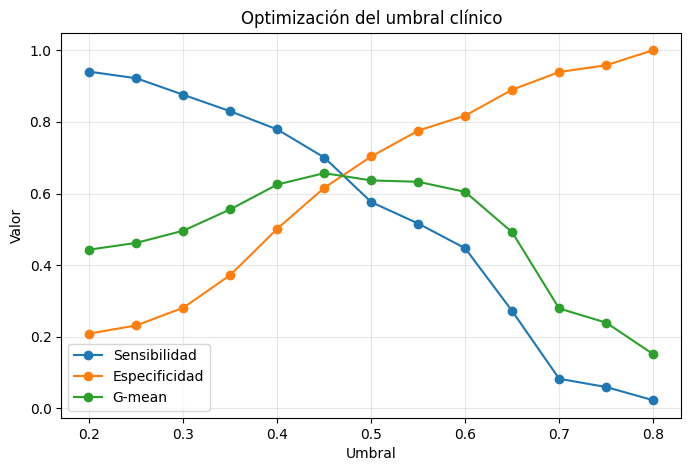

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    df_umbrales["umbral"],
    df_umbrales["sensibilidad"],
    marker="o",
    label="Sensibilidad"
)

plt.plot(
    df_umbrales["umbral"],
    df_umbrales["especificidad"],
    marker="o",
    label="Especificidad"
)

plt.plot(
    df_umbrales["umbral"],
    df_umbrales["g_mean"],
    marker="o",
    label="G-mean"
)

plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.title("Optimización del umbral clínico")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Aunque la optimización del umbral mostró que valores comprendidos entre 0.40 y 0.45 proporcionan mejores resultados en términos de sensibilidad, balanced accuracy y G-mean, se decidió mantener el umbral estándar de 0.50. Esta decisión se fundamenta en varios aspectos.

En primer lugar, el umbral de 0.50 corresponde al criterio de decisión por defecto utilizado por la regresión logística binaria, lo que facilita la interpretación clínica y la comparación con otros estudios. Además, fue el criterio empleado implícitamente durante la fase previa de selección de variables mediante algoritmo genético, garantizando la coherencia metodológica del trabajo.

Por otra parte, aunque umbrales inferiores permiten reducir el número de falsos negativos, también incrementan notablemente el número de falsos positivos. El umbral de 0.50 proporciona un equilibrio razonable entre sensibilidad (57.6%) y especificidad (70.3%), manteniendo una capacidad discriminativa adecuada sin aumentar excesivamente las clasificaciones erróneas.

Por estos motivos, se optó por conservar el umbral de decisión estándar de 0.50 para el desarrollo y evaluación final del modelo predictivo.

**Informes de clasificación**

In [22]:
print("Classification report - Baseline")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["No hipertensión", "Hipertensión"]
))

print("\nClassification report - Modelo calibrado")
print(classification_report(
    y_test,
    y_pred_calibrated,
    target_names=["No hipertensión", "Hipertensión"]
))

Classification report - Baseline
                 precision    recall  f1-score   support

No hipertensión       0.69      0.66      0.67       263
   Hipertensión       0.61      0.64      0.62       217

       accuracy                           0.65       480
      macro avg       0.65      0.65      0.65       480
   weighted avg       0.65      0.65      0.65       480


Classification report - Modelo calibrado
                 precision    recall  f1-score   support

No hipertensión       0.67      0.70      0.69       263
   Hipertensión       0.62      0.58      0.60       217

       accuracy                           0.65       480
      macro avg       0.64      0.64      0.64       480
   weighted avg       0.64      0.65      0.64       480



**Matrices de confusión**

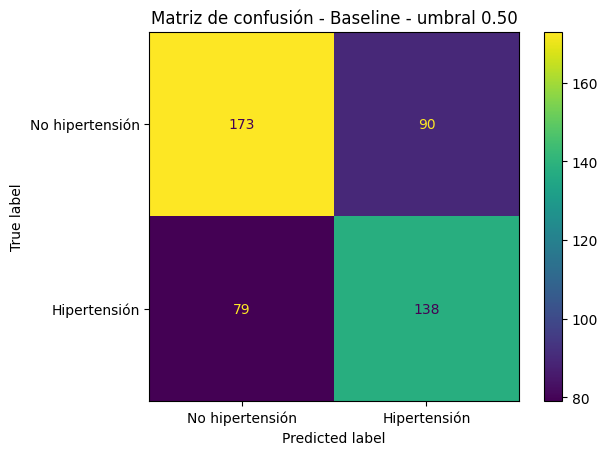

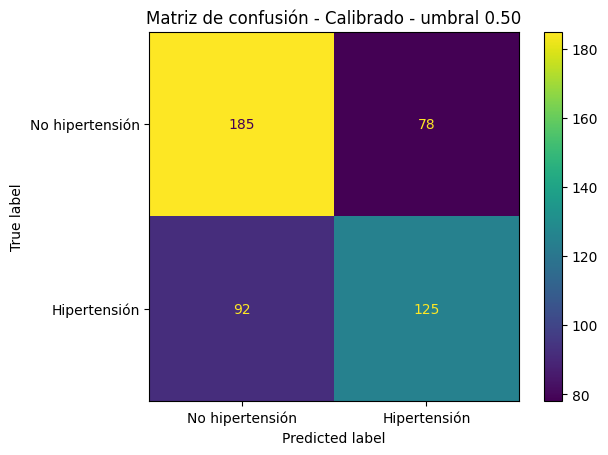

In [23]:
for nombre_modelo, y_pred in {
    "Baseline": y_pred_baseline,
    "Calibrado": y_pred_calibrated
}.items():

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No hipertensión", "Hipertensión"]
    )

    disp.plot(values_format="d")
    plt.title(f"Matriz de confusión - {nombre_modelo} - umbral 0.50")
    plt.show()

## 7. Curva de calibración

Esta gráfica compara la probabilidad predicha con la frecuencia real observada.

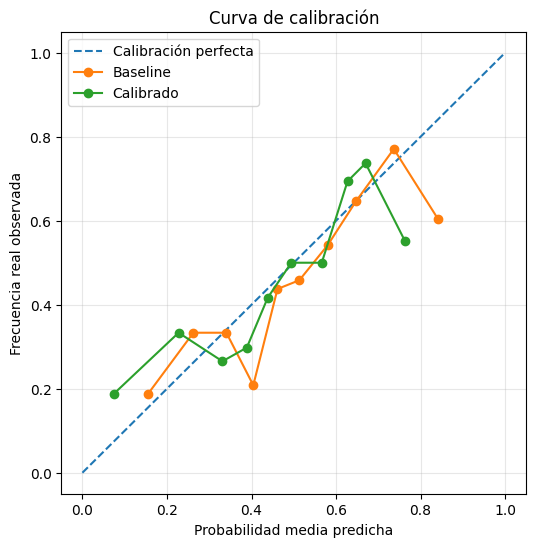

In [28]:
modelos_calibracion = {
    "Baseline": y_proba_baseline,
    "Calibrado": y_proba_calibrated
}

plt.figure(figsize=(6, 6))

plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")

for nombre_modelo, y_proba_modelo in modelos_calibracion.items():
    prob_true, prob_pred = calibration_curve(
        y_test,
        y_proba_modelo,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(prob_pred, prob_true, marker="o", label=nombre_modelo)

plt.xlabel("Probabilidad media predicha")
plt.ylabel("Frecuencia real observada")
plt.title("Curva de calibración")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Gráfico de baseline predictions vs calibration predictions**

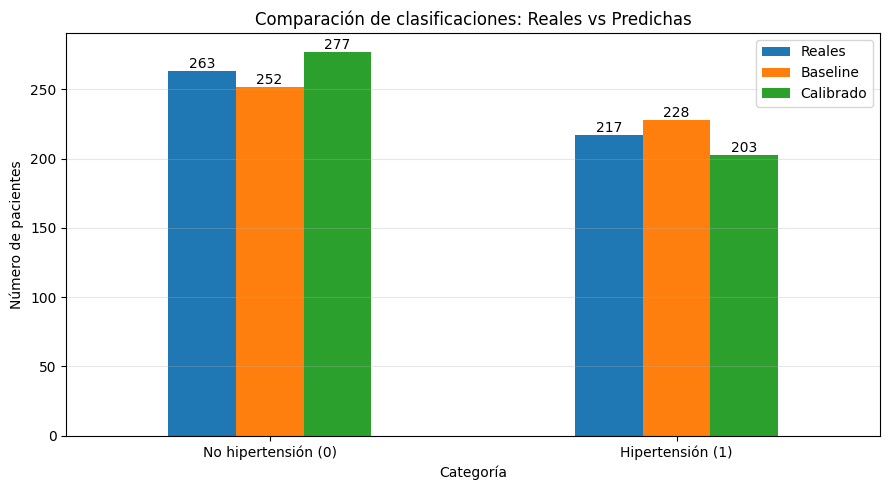

In [36]:
conteo_reales = y_test.value_counts().sort_index()
conteo_baseline = pd.Series(y_pred_baseline).value_counts().sort_index()
conteo_calibrado = pd.Series(y_pred_calibrated).value_counts().sort_index()

df_barras = pd.DataFrame({
    "Reales": conteo_reales,
    "Baseline": conteo_baseline,
    "Calibrado": conteo_calibrado
}).fillna(0).astype(int)

df_barras.index = ["No hipertensión (0)", "Hipertensión (1)"]

ax = df_barras.plot(
    kind="bar",
    figsize=(9, 5),
    rot=0
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Comparación de clasificaciones: Reales vs Predichas")
plt.xlabel("Categoría")
plt.ylabel("Número de pacientes")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Tabla final con porcentaje de probabilidad de hipertensión

Se genera una tabla con:

- probabilidad en escala 0-1;
- probabilidad en porcentaje;
- categoría de riesgo orientativa.

Las categorías de riesgo son descriptivas, pueden y deben ajustarse a criterio clínico.

In [ ]:
def categorizar_riesgo(prob):
    if prob < 0.30:
        return "Bajo"
    elif prob < 0.60:
        return "Moderado"
    else:
        return "Alto"

resultados_probabilidad = pd.DataFrame(index=X_test.index)

resultados_probabilidad["y_real"] = y_test.values

# Baseline
resultados_probabilidad["probabilidad_baseline"] = y_proba_baseline
resultados_probabilidad["probabilidad_baseline_%"] = (
    y_proba_baseline * 100
).round(2)
resultados_probabilidad["prediccion_baseline"] = y_pred_baseline
resultados_probabilidad["riesgo_baseline"] = [
    categorizar_riesgo(p)
    for p in y_proba_baseline
]

# Calibrado
resultados_probabilidad["probabilidad_calibrada"] = y_proba_calibrated
resultados_probabilidad["probabilidad_calibrada_%"] = (
    y_proba_calibrated * 100
).round(2)
resultados_probabilidad["prediccion_calibrada"] = y_pred_calibrated
resultados_probabilidad["riesgo_calibrado"] = [
    categorizar_riesgo(p)
    for p in y_proba_calibrated
]

cols_resumen = [
    "y_real",
    "probabilidad_baseline_%",
    "prediccion_baseline",
    "riesgo_baseline",
    "probabilidad_calibrada_%",
    "prediccion_calibrada",
    "riesgo_calibrado"
]

resultados_probabilidad[cols_resumen].head(20)

,y_real,probabilidad_baseline_%,prediccion_baseline,riesgo_baseline,probabilidad_calibrada_%,prediccion_calibrada,riesgo_calibrado
0,0,6.17,0,Bajo,0.00,0,Bajo
1,1,85.82,1,Alto,75.94,1,Alto
2,1,58.63,1,Moderado,54.77,1,Moderado
3,0,32.60,0,Moderado,31.89,0,Moderado
4,0,38.65,0,Moderado,38.55,0,Moderado
5,0,24.54,0,Bajo,22.38,0,Bajo
6,1,58.36,1,Moderado,57.67,1,Moderado
7,0,18.63,0,Bajo,10.11,0,Bajo
8,1,62.02,1,Alto,61.72,1,Alto
9,0,49.97,0,Moderado,46.04,0,Moderado


In [30]:
output_probs_path = OUTPUT_DIR / "probabilidad_hipertension_test_LogisticRegression_GA.csv"
resultados_probabilidad.to_csv(output_probs_path, index=False)
print(f"Archivo guardado en: {output_probs_path.resolve()}")

Archivo guardado en: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_probhipertension\probabilidad_hipertension_test_LogisticRegression_GA.csv


## 9. Función para predecir nuevos pacientes

La función `predecir_probabilidad_hipertension` recibe un dataframe con las mismas variables originales y devuelve el porcentaje de probabilidad de hipertensión.

In [41]:
def predecir_probabilidad_hipertension(
    nuevo_df: pd.DataFrame
) -> pd.DataFrame:

    missing = [v for v in selected_vars if v not in nuevo_df.columns]

    if missing:
        raise ValueError(
            "Faltan variables necesarias para la predicción:\n"
            + "\n".join(missing)
        )

    X_nuevo = nuevo_df[selected_vars].copy()

    probas = baseline_model.predict_proba(X_nuevo)[:, 1]
    preds = (probas >= 0.50).astype(int)

    salida = pd.DataFrame({
        "probabilidad_hipertension_%": (probas * 100).round(2),
        "categoria_riesgo": [
            categorizar_riesgo(p)
            for p in probas
        ]
    },
    index=nuevo_df.index)

    return salida

**Ejemplo de Uso**

In [42]:
# Simulación de un nuevo paciente
paciente = X_test.iloc[[0]].copy()

print("Características del paciente:")
display(paciente)

print("\nPredicción del modelo:")
display(
    predecir_probabilidad_hipertension(paciente)
)

Características del paciente:


,estado_examen_balance_1,rigidez_iqr,cap_iqr,intentos_totales_elasto,fracturas_1,largo_brazo_superior_cm,mercurio_sangre_nmol_l,periodo_examen_1,raza_etnia_4.0,tiempo_seg_cond3,...,volumen_plaquetario_medio,ancho_distribucion_eritrocitos,medidas_validas_elasto,conc_hemoglobina_media,tamano_hogar,pulso,plaquetas_totales,edad_an,trigliceridos_mmol_l,raza_etnia_2.0
0,1.0,0.113743,-0.36846,1.017994,0.0,1.166613,0.064204,0.0,0.0,0.162136,...,0.489648,-0.789089,2.32681,2.192189,-0.475576,-0.949885,-0.76286,-1.369504,-0.943901,0.0



Predicción del modelo:


,probabilidad_hipertension_%,categoria_riesgo
0,6.17,Bajo


## 10. Guardado del modelo

Se guarda el modelo completo calibrado, junto con la lista de variables seleccionadas. Esto permite reutilizarlo después sin reentrenar.

In [43]:
model_path = (
    OUTPUT_DIR /
    "modelo_probabilidad_hipertension_LogisticRegression_GA_baseline.joblib"
)
vars_path = (
    OUTPUT_DIR /
    "variables_usadas_modelo_LogisticRegression_GA.csv"
)
metrics_path = (
    OUTPUT_DIR /
    "metricas_modelo_LogisticRegression_GA_baseline.csv"
)

joblib.dump(
    {
        "model": baseline_model,
        "selected_vars": selected_vars,
        "threshold": 0.50,
        "risk_categories": {
            "Bajo": "probabilidad < 30%",
            "Moderado": "30% <= probabilidad < 60%",
            "Alto": "probabilidad >= 60%"
        }
    },
    model_path
)

pd.DataFrame(
    {"variable": selected_vars}
).to_csv(
    vars_path,
    index=False
)

pd.DataFrame(
    [metricas_baseline]
).to_csv(
    metrics_path,
    index=False
)

print(f"Modelo guardado en: {model_path.resolve()}")
print(f"Variables guardadas en: {vars_path.resolve()}")
print(f"Métricas guardadas en: {metrics_path.resolve()}")

Modelo guardado en: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_probhipertension\modelo_probabilidad_hipertension_LogisticRegression_GA_baseline.joblib
Variables guardadas en: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_probhipertension\variables_usadas_modelo_LogisticRegression_GA.csv
Métricas guardadas en: C:\Users\Usuario\Documents\GitHub\hypertension_management_AI_driven_tool\output_probhipertension\metricas_modelo_LogisticRegression_GA_baseline.csv


## Conclusión

Este notebook deja preparado un flujo reproducible para obtener el **porcentaje de probabilidad de hipertensión** usando exclusivamente las variables seleccionadas por el algoritmo genético de `LogisticRegression` sin Grid.

La salida principal es:

`output_probabilidad_hipertension/probabilidad_hipertension_test_LogisticRegression_GA.csv`

La columna clave es:

`probabilidad_hipertension_%`